In [4]:
import pandas as pd

df=pd.read_csv('OmniWeb.txt', sep=r'\s+')

# Cambiamos el formato
df['Fecha_Hora_UTC']=pd.to_datetime(df[['YEAR', 'DOY', 'HR']].astype(str).agg('-'.join,axis=1), format='%Y-%j-%H')

# Reescribimos el como es
df['Fecha_Hora_UTC']=df['Fecha_Hora_UTC'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Renombramos columnas
df=df.rename(columns={'1':'nT(Bz)'})
df=df.rename(columns={'2':'K'})
df=df.rename(columns={'3':'N/cm3'})
df=df.rename(columns={'4':'km/s'})

Remplazar=[999.9, 9999999.0, 9999.0]

# Remplazamos 
df.replace(Remplazar, '', inplace=True)

df=df[['Fecha_Hora_UTC', 'nT(Bz)', 'K', 'N/cm3', 'km/s']]

df.to_csv('ParametrosNasa.txt', sep='\t', index=False)

print(df)


            Fecha_Hora_UTC nT(Bz)         K N/cm3   km/s
0      2023-09-14 00:00:00   -3.9   88907.0   6.1  376.0
1      2023-09-14 01:00:00   -3.7   89140.0   6.4  380.0
2      2023-09-14 02:00:00    0.1   95131.0   5.6  365.0
3      2023-09-14 03:00:00   -1.6   99347.0   5.4  382.0
4      2023-09-14 04:00:00    1.8  127413.0   6.7  408.0
...                    ...    ...       ...   ...    ...
19027  2025-11-14 19:00:00          34271.0   1.0  565.0
19028  2025-11-14 20:00:00          50915.0   1.1  579.0
19029  2025-11-14 21:00:00          46044.0   1.0  569.0
19030  2025-11-14 22:00:00          43265.0   1.0  564.0
19031  2025-11-14 23:00:00          56149.0   1.0  567.0

[19032 rows x 5 columns]


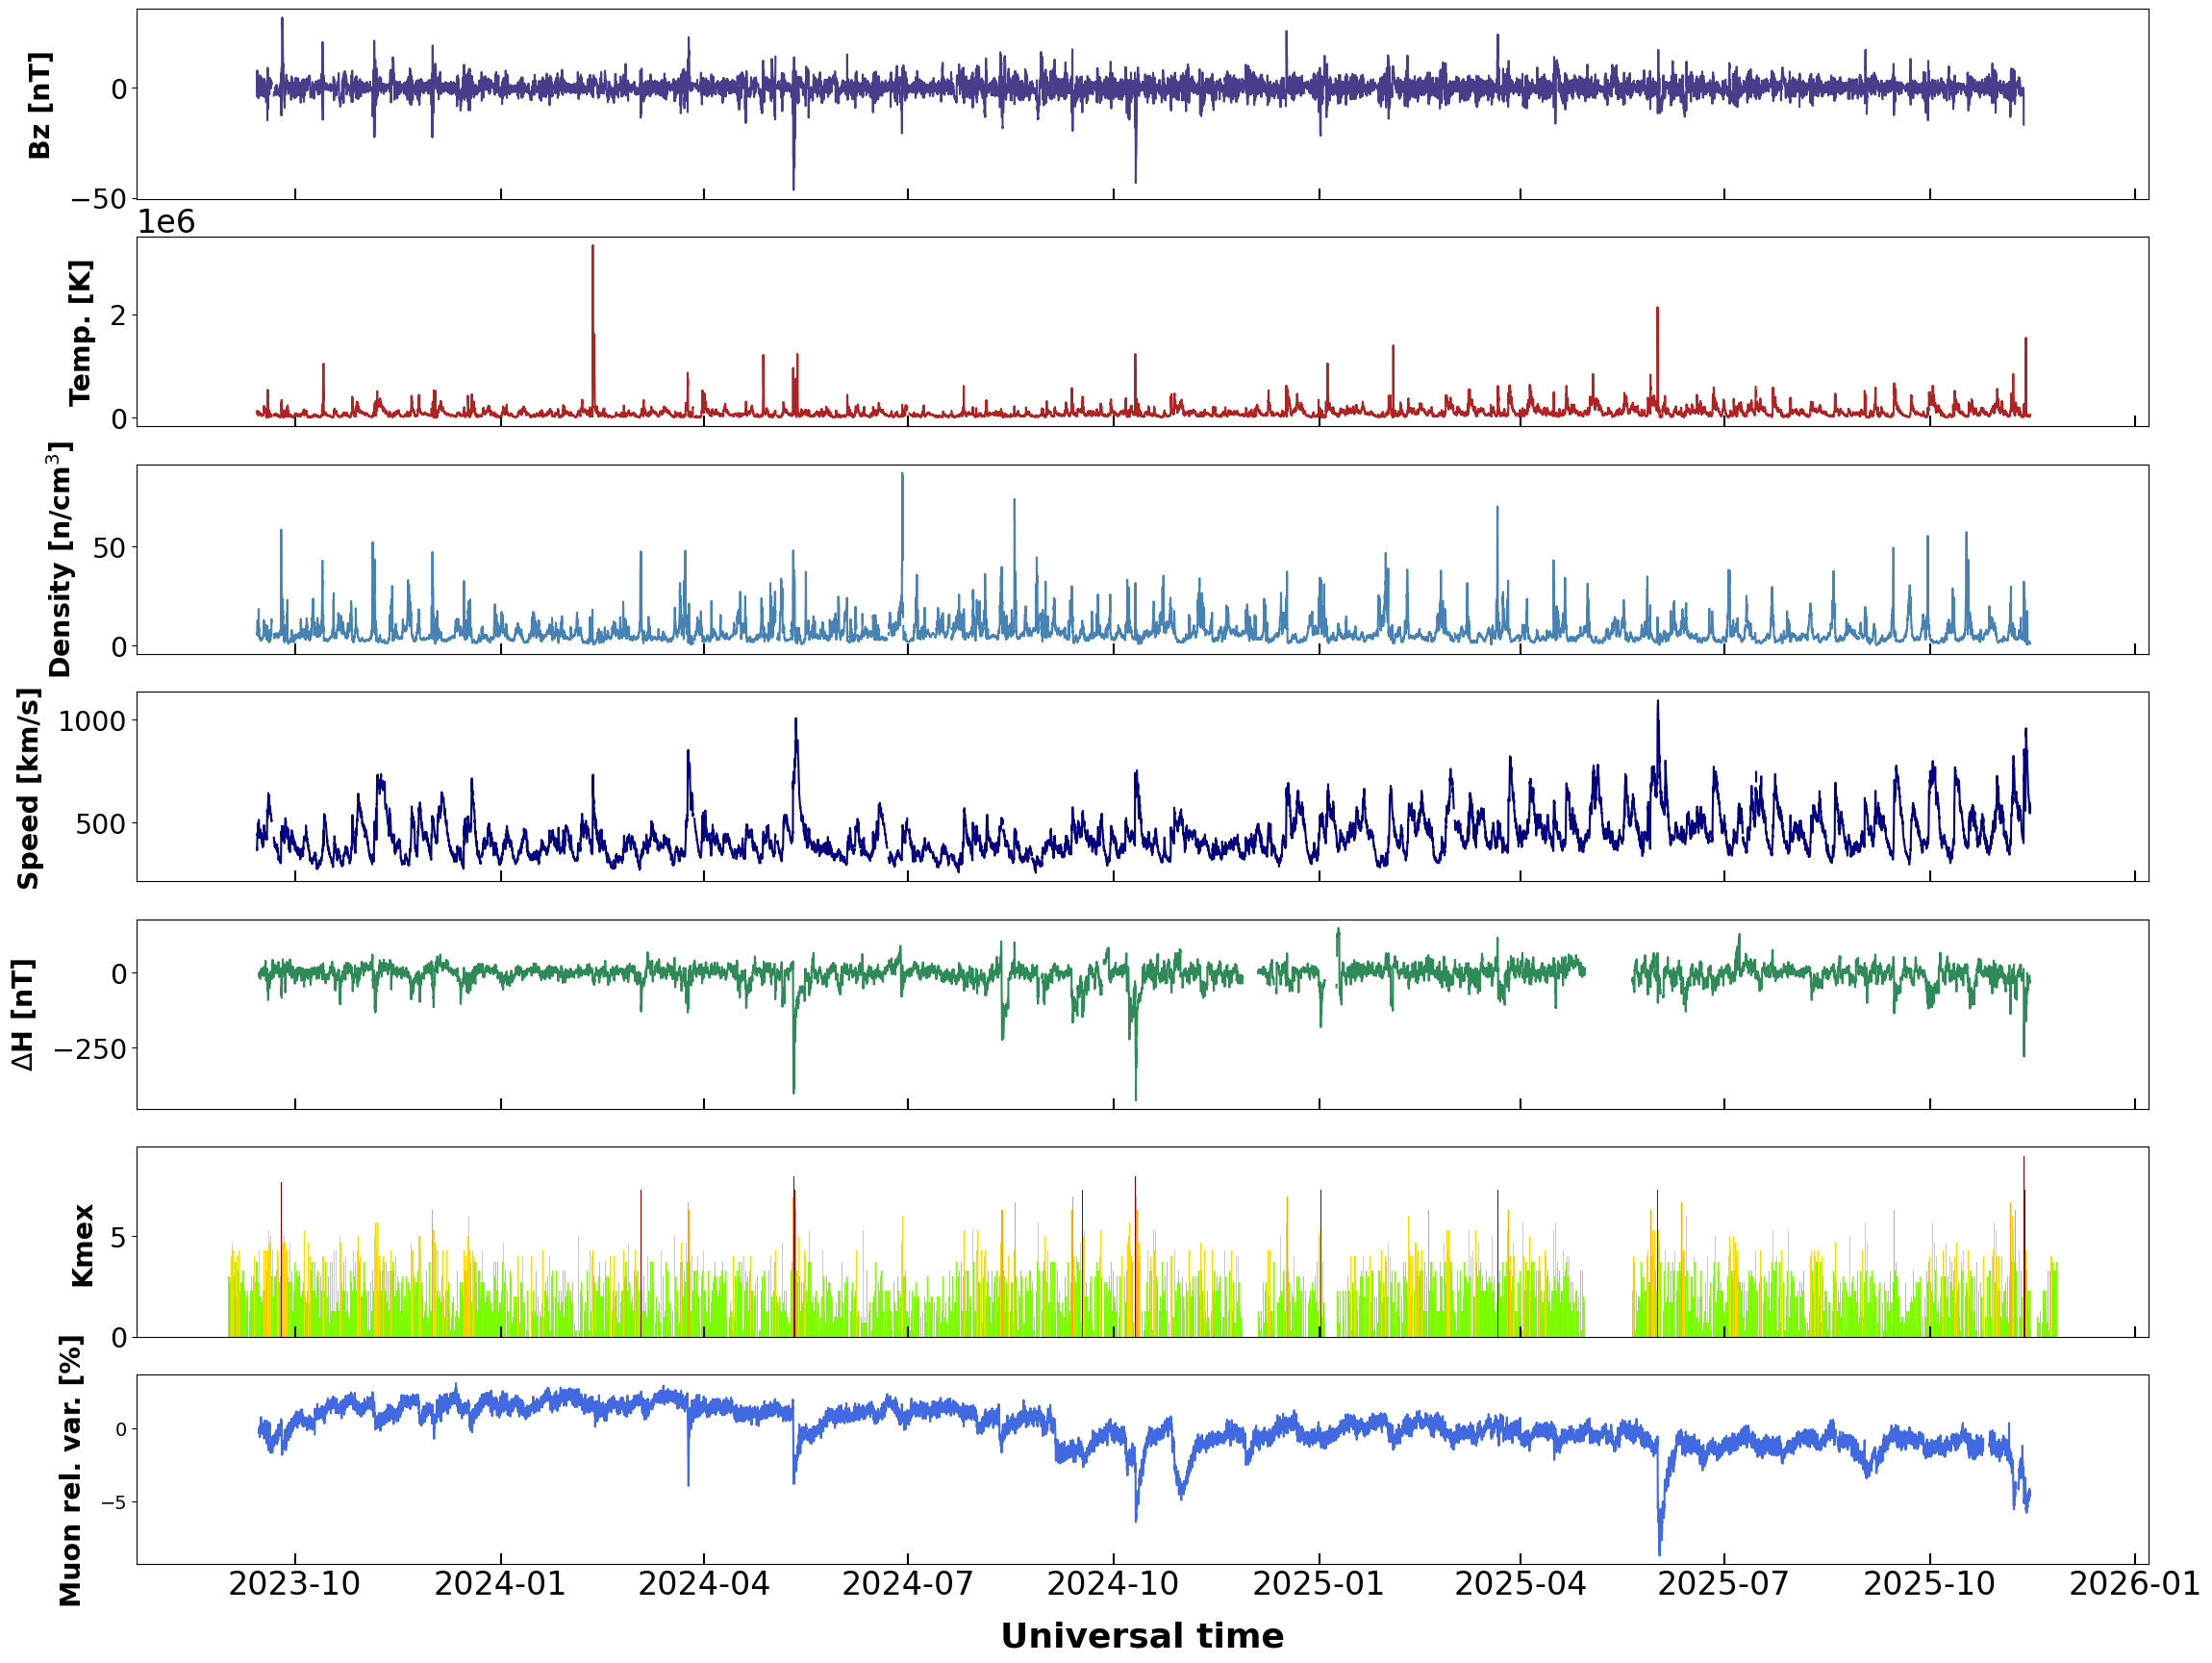

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.ticker import ScalarFormatter

Archivos=['ParametrosNasa.txt', 'ParametrosNasa.txt', 'ParametrosNasa.txt', 'ParametrosNasa.txt', 'DataCorrFinal_UTC.txt']
Colores=['darkslateblue', 'firebrick', 'steelblue', 'navy', 'seagreen']
COLGRAF=['nT(Bz)', 'K', 'N/cm3', 'km/s', 'DeltaH']
Nombres=['Bz [nT]', 'Temp. [K]', r'Density [n/cm$^3$]', 'Speed [km/s]', r'$\Delta$H [nT]']

fig, ax=plt.subplots(nrows=7, ncols=1, figsize=(27,21), sharex=True)

#OMNIWeb
for i, Archivo in enumerate(Archivos):
    df=pd.read_csv(Archivo,sep='\t')

    df['Fecha_Hora_UTC']=pd.to_datetime(df['Fecha_Hora_UTC'], format='%Y-%m-%d %H:%M:%S')
    Iterada=COLGRAF[i]

    ax[i].plot(df['Fecha_Hora_UTC'], df[Iterada], marker='None', color=Colores[i], linestyle='-')
    #ax[i].set_ylabel(Nombres[i], fontsize=20.5, labelpad=10)
    ax[i].set_ylabel(Nombres[i], fontsize=20.5, labelpad=10, fontweight='black')
    ax[i].tick_params(axis='y', labelsize=20.5)
    ax[i].tick_params(axis='x', which='both', direction='in', length=8, width=1.5, top=False, bottom=True, labelsize=24)

    if Iterada=='K':
        ax[i].ticklabel_format(axis='y', style='sci', scilimits=(6,6))
        ax[i].yaxis.offsetText.set_fontsize(24) # Notación cientifica de la temperatura

# Kmex
df_Kmex=pd.read_csv('Km2325.txt', sep='\t')
df_Kmex['Fecha_Hora']=pd.to_datetime(df_Kmex['Fecha_Hora'], format='%Y-%m-%d %H:%M:%S')

for i, (fecha_hora, valork) in enumerate(zip(df_Kmex['Fecha_Hora'], df_Kmex['Valor_K'])):
    if valork<4:
        color='lawngreen'
    elif 4<= valork<=6:
        color='gold'
    elif 6<=valork<=7:
        color='orange'
    else:
        color='darkred'
    # Posición de Kmex
    ax[-2].bar(fecha_hora, valork, width=0.124, color=color) 

    ax[-2].set_ylabel('Kmex', fontsize=20.5, labelpad=10, fontweight='black')
    ax[-2].tick_params(axis='y', labelsize=20.5)
    ax[-2].tick_params(axis='x', which='both', direction='in', length=8, width=1.5, top=False, bottom=True, labelsize=24)

# ICN

df_ICN=pd.read_csv('DataCorrFinal_UTC.txt', sep='\t')
df_ICN['Fecha_Hora_UTC']=pd.to_datetime(df_ICN['Fecha_Hora_UTC'], format='%Y-%m-%d %H:%M:%S')
Ponderado=235772.19950858603
df_ICN['VarDataCorr']=100*(df_ICN['ICNCorr']-Ponderado)/Ponderado

ax[-1].plot(df_ICN['Fecha_Hora_UTC'], df_ICN['VarDataCorr'], color='royalblue', label='corr')
ax[-1].set_ylabel('Muon rel. var. [%]', fontsize=20.5, labelpad=10, fontweight='black')
ax[-1].tick_params(axis='y', labelsize=14)
ax[-1].tick_params(axis='x', which='both', direction='in', length=8, width=1.5, top=False, bottom=True, labelsize=24)
ax[-1].set_xlabel('Universal time', fontsize=26, labelpad=15, fontweight='black')

locator = mdates.MonthLocator(interval=2) # Mostrar marca cada 7 días
formatter = mdates.DateFormatter('%Y/%m') # Formato día/mes/año

plt.savefig('Parametros.png')

plt.show()


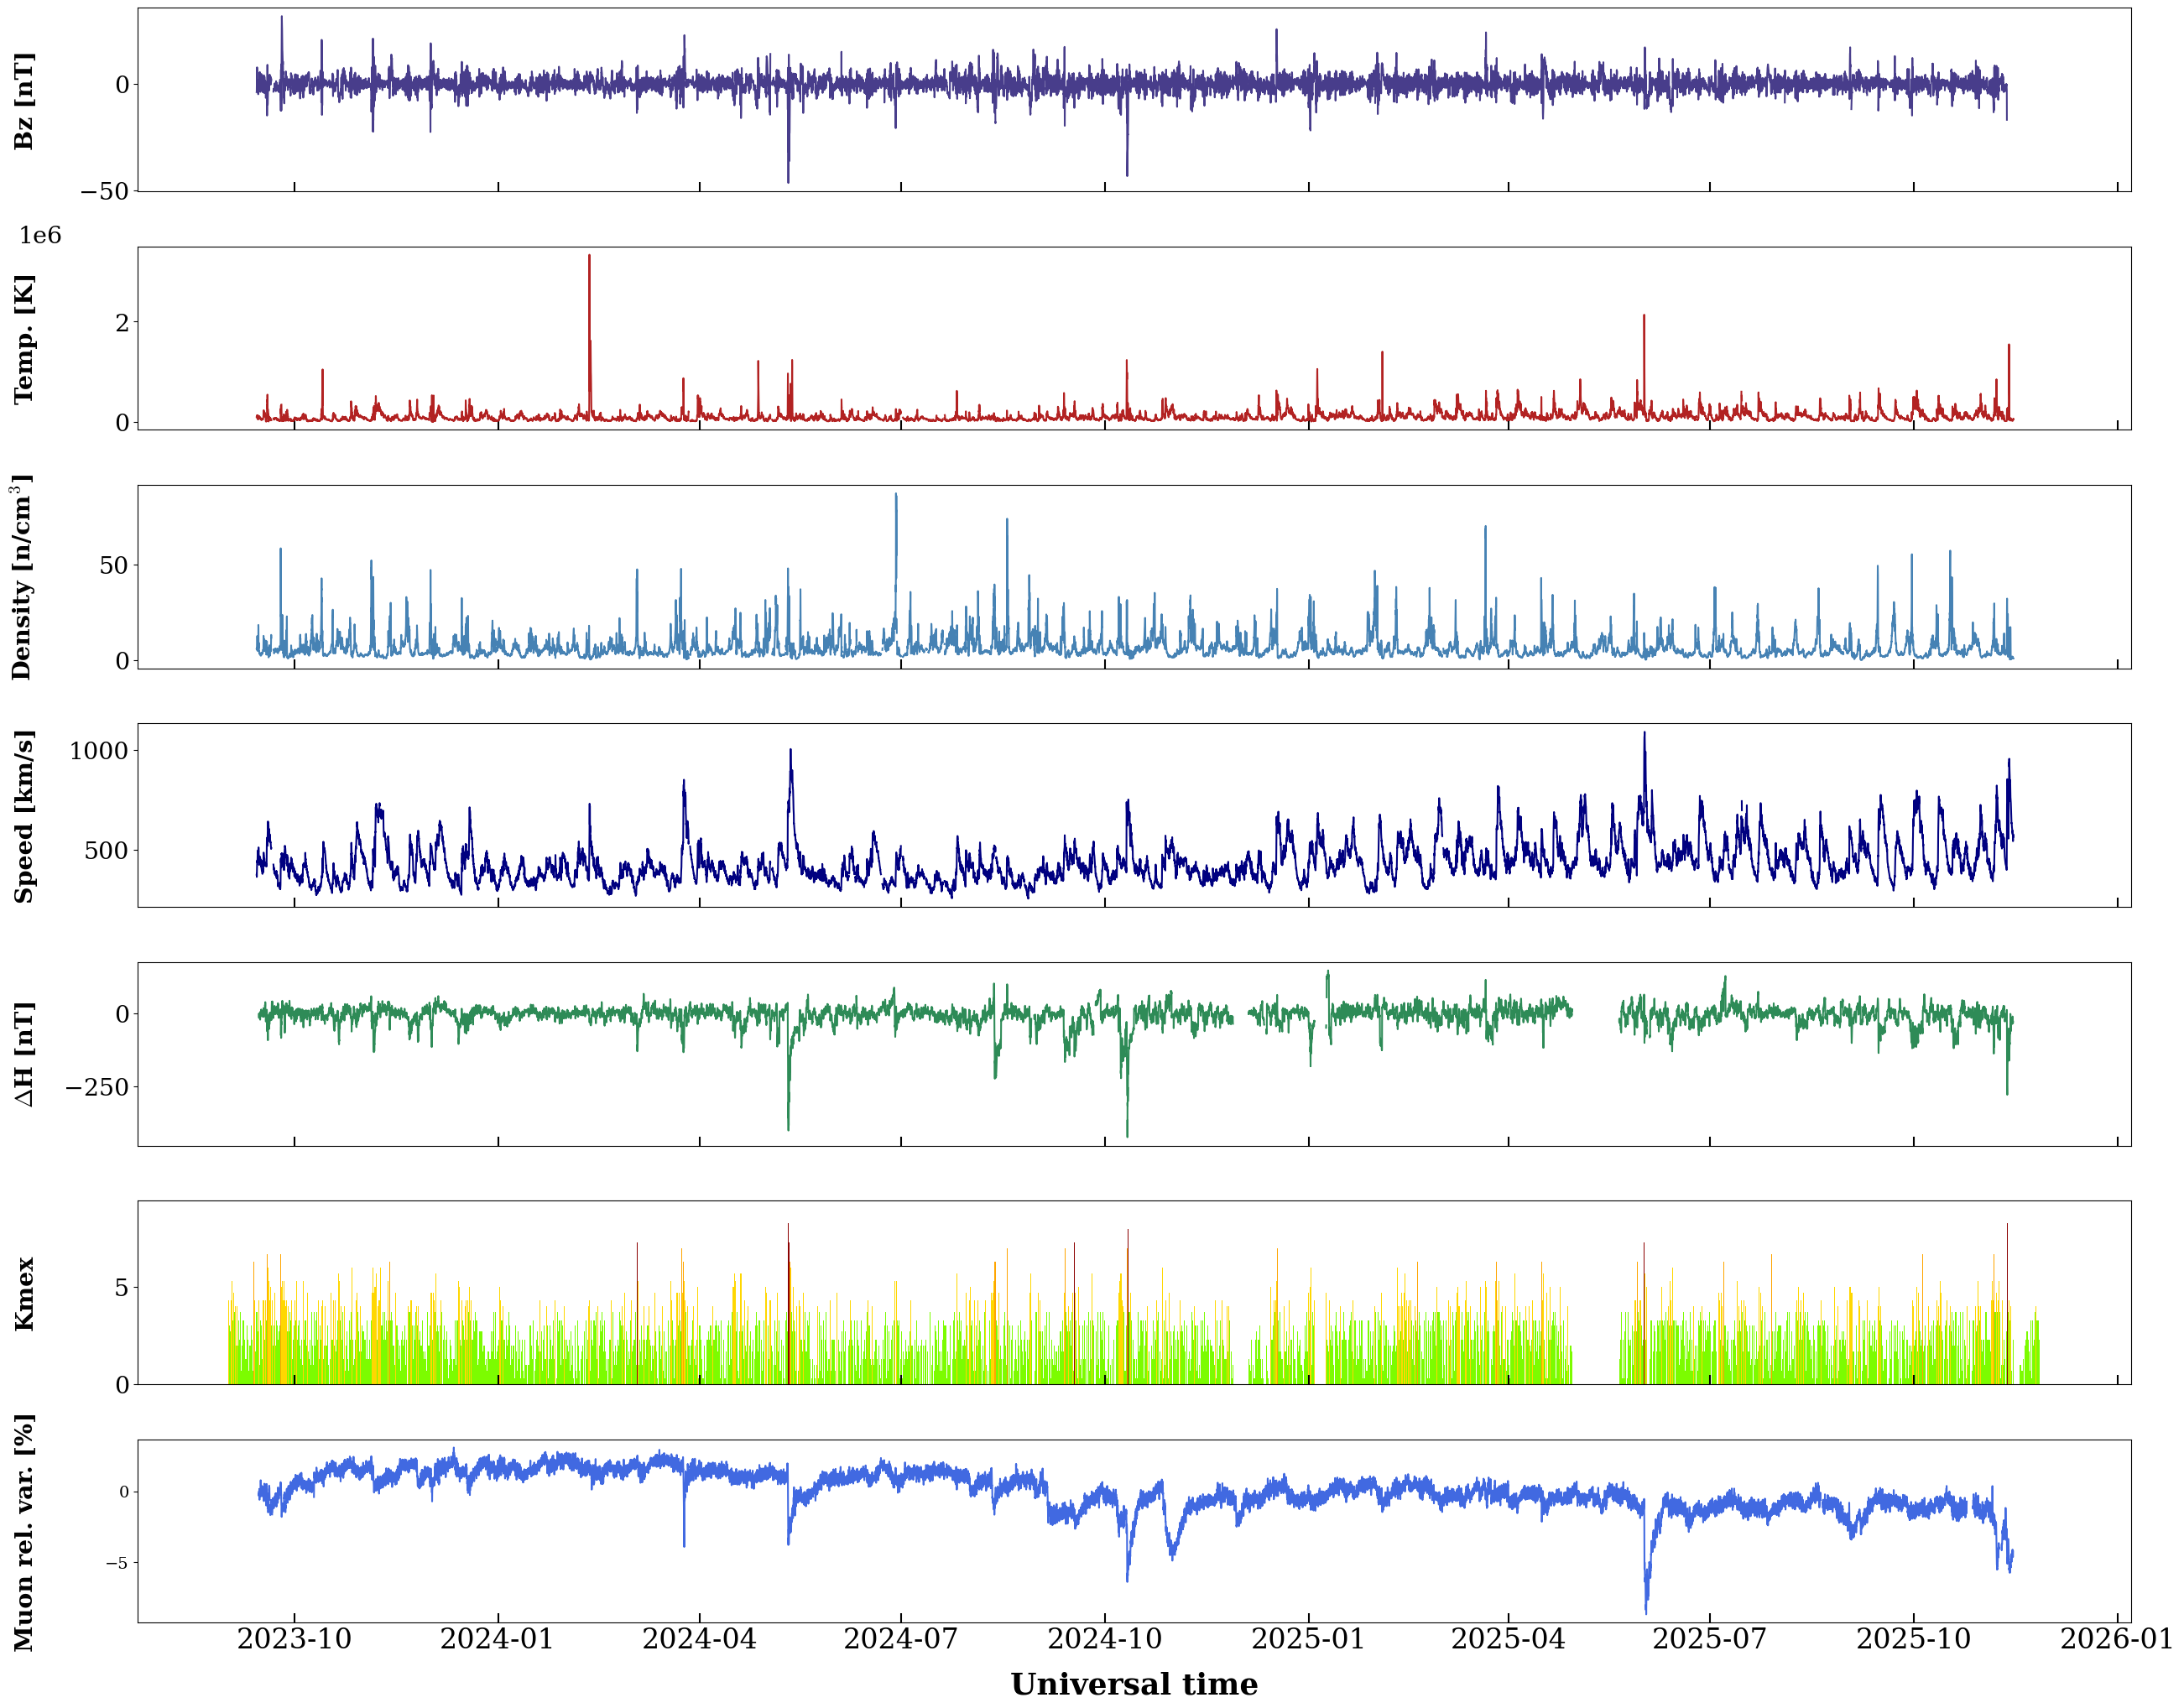

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.ticker import ScalarFormatter

# --- CONFIGURACIÓN DE FUENTE Y MATHTEXT ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
# ------------------------------------------

Archivos=['ParametrosNasa.txt', 'ParametrosNasa.txt', 'ParametrosNasa.txt', 'ParametrosNasa.txt', 'DataCorrFinal_UTC.txt']
Colores=['darkslateblue', 'firebrick', 'steelblue', 'navy', 'seagreen']
COLGRAF=['nT(Bz)', 'K', 'N/cm3', 'km/s', 'DeltaH']
Nombres=['Bz [nT]', 'Temp. [K]', r'Density [n/cm$^3$]', 'Speed [km/s]', r'$\Delta$H [nT]']

# 💡 AUMENTAR EL TAMAÑO VERTICAL DE LA FIGURA para tener más espacio para distribuir
fig, ax=plt.subplots(nrows=7, ncols=1, figsize=(27,25), sharex=True) 
# Original era figsize=(27,21). El aumento a 25 da más margen.

# ⭐️ POSICIÓN HORIZONTAL FIJA PARA LEYENDAS VERTICALES ⭐️
# Mantenemos un valor negativo para centrar las etiquetas verticalmente
X_COORD_LABEL_POS = -0.05 

#OMNIWeb
for i, Archivo in enumerate(Archivos):
    df=pd.read_csv(Archivo,sep='\t')

    df['Fecha_Hora_UTC']=pd.to_datetime(df['Fecha_Hora_UTC'], format='%Y-%m-%d %H:%M:%S')
    Iterada=COLGRAF[i]

    color_actual = 'darkslateblue' if Nombres[i] == 'Bz [nT]' else Colores[i]
    
    ax[i].plot(df['Fecha_Hora_UTC'], df[Iterada], marker='None', color=color_actual, linestyle='-')
    
    # Alineación vertical de la leyenda Y
    ax[i].set_ylabel(Nombres[i], fontsize=20.5, labelpad=10, fontweight='black')
    ax[i].yaxis.set_label_coords(X_COORD_LABEL_POS, 0.5) 
    
    ax[i].tick_params(axis='y', labelsize=20.5)
    ax[i].tick_params(axis='x', which='both', direction='in', length=8, width=1.5, top=False, bottom=True, labelsize=24)

    if Iterada=='K':
        ax[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0)) 
        ax[i].yaxis.offsetText.set_fontsize(20.5)
        ax[i].yaxis.get_offset_text().set_x(-0.06) 
        
# Kmex (ax[5])
df_Kmex=pd.read_csv('Km2325.txt', sep='\t')
df_Kmex['Fecha_Hora']=pd.to_datetime(df_Kmex['Fecha_Hora'], format='%Y-%m-%d %H:%M:%S')

# ... (bucle para barras de Kmex) ...
for i, (fecha_hora, valork) in enumerate(zip(df_Kmex['Fecha_Hora'], df_Kmex['Valor_K'])):
    if valork<4:
        color='lawngreen'
    elif 4<= valork<=6:
        color='gold'
    elif 6<=valork<=7:
        color='orange'
    else:
        color='darkred'
    ax[5].bar(fecha_hora, valork, width=0.124, color=color) 

    ax[5].set_ylabel('Kmex', fontsize=20.5, labelpad=10, fontweight='black')
    ax[5].yaxis.set_label_coords(X_COORD_LABEL_POS, 0.5)

    ax[5].tick_params(axis='y', labelsize=20.5)
    ax[5].tick_params(axis='x', which='both', direction='in', length=8, width=1.5, top=False, bottom=True, labelsize=24)

# ICN (Muon rel. var.) (ax[6])

df_ICN=pd.read_csv('DataCorrFinal_UTC.txt', sep='\t')
df_ICN['Fecha_Hora_UTC']=pd.to_datetime(df_ICN['Fecha_Hora_UTC'], format='%Y-%m-%d %H:%M:%S')
Ponderado=235772.19950858603
df_ICN['VarDataCorr']=100*(df_ICN['ICNCorr']-Ponderado)/Ponderado

ax[6].plot(df_ICN['Fecha_Hora_UTC'], df_ICN['VarDataCorr'], color='royalblue', label='corr')

ax[6].set_ylabel('Muon rel. var. [%]', fontsize=20.5, labelpad=10, fontweight='black')
ax[6].yaxis.set_label_coords(X_COORD_LABEL_POS, 0.5)

ax[6].tick_params(axis='y', labelsize=14)
ax[6].tick_params(axis='x', which='both', direction='in', length=8, width=1.5, top=False, bottom=True, labelsize=24)
ax[6].set_xlabel('Universal time', fontsize=26, labelpad=15, fontweight='black')

locator = mdates.MonthLocator(interval=2) 
formatter = mdates.DateFormatter('%Y/%m') 

# ⭐️ CAMBIO CLAVE AQUÍ: Aumentamos hspace a 0.3 para crear más espacio entre subplots
plt.subplots_adjust(left=0.10, right=0.98, hspace=0.3)

plt.savefig('ParametrosBuenos.png')
plt.show()